In [ ]:
!pip install natsort

from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import random
from natsort import natsorted, os_sorted, ns
import time
import datetime
import random

In [ ]:
import kagglehub

path = kagglehub.dataset_download("arbazkhan971/cuhk-face-sketch-database-cufs")

print("Path to dataset files:", path)

100%|██████████| 113M/113M [00:01<00:00, 72.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1


In [ ]:
import numpy as np
import pandas as pd

data_paths = []
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1'):
    print(dirname)
    for filename in filenames:
        data_paths.append(os.path.join(dirname, filename))

print("total number of data:", len(data_paths))

/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1
/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/photo
/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/original_sketch
/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/sketch_points
/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/photos
/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/cropped_sketch
/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/sketch
/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/sketches
/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/photo_points
total number of data: 5716


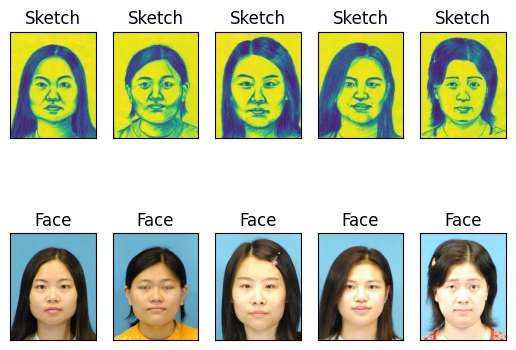

In [ ]:
portrait_path = r"/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/photos"
sketches_path = r"/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/sketches"

portrait_imgname = os.listdir(portrait_path)
sketches_imgname = os.listdir(sketches_path)

portrait_imgname = natsorted(portrait_imgname, alg=ns.IGNORECASE)
sketches_imgname = natsorted(sketches_imgname, alg=ns.IGNORECASE)

portrait_imgs = [portrait_path+"/"+imgname for imgname in portrait_imgname]
sketches_imgs = [sketches_path+"/"+imgname for imgname in sketches_imgname]

imgnum = 5
imgrow = 2

for i in range(imgnum):
    face = Image.open(portrait_imgs[i])
    sketch = Image.open(sketches_imgs[i])

    # 🔹 FIRST ROW → SKETCH (INPUT)
    ax = plt.subplot(imgrow, imgnum, i+1)
    plt.title("Sketch")
    plt.imshow(sketch)
    plt.xticks([])
    plt.yticks([])

    # 🔹 SECOND ROW → FACE (TARGET)
    ax = plt.subplot(imgrow, imgnum, i+imgnum+1)
    plt.title("Face")
    plt.imshow(face)
    plt.xticks([])
    plt.yticks([])

Data Preprocessing

In [ ]:
def load(image_path):
    image = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image, channels=IN_CHANNEL)
    image = tf.cast(image, tf.float32)
    return image

def resize(image, height, width):
    image = tf.image.resize(image, [height, width],
                            method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    return image

def normalize(image):
    image = (image / 127.5) - 1
    return image

def denormalize(image):
    # Convert from [-1, 1] → [0, 255] for face image visualization
    image = (image + 1.0) * 127.5
    return tf.clip_by_value(image, 0, 255)

# data augmentation
def flip(image):
    image = tf.image.flip_left_right(image)
    return image

adjustment_seed = 1
random.seed(adjustment_seed)

def random_adjustment(image1, image2):
    rand_bright = random.uniform(1, 5)
    rand_contrast = random.uniform(1, 2)

    image1 = tf.image.adjust_brightness(image1, delta=rand_bright)
    image2 = tf.image.adjust_brightness(image2, delta=rand_bright)

    image1 = tf.image.adjust_contrast(image1, contrast_factor=rand_contrast)
    image2 = tf.image.adjust_contrast(image2, contrast_factor=rand_contrast)

    image1 = tf.cast(image1, tf.float32)
    image2 = tf.cast(image2, tf.float32)

    return image1, image2

IMG_SIZE = 256

IN_CHANNEL = 3
OUT_CHANNEL = IN_CHANNEL

TRAIN_BATCH = 4

In [ ]:
tempsize = 4
imgs = []

for i in range(tempsize):
    # 🔹 LOAD SKETCH FIRST (INPUT)
    img1 = load(sketches_imgs[i])
    img1 = resize(img1, IMG_SIZE, IMG_SIZE)
    img1 = normalize(img1)

    # 🔹 LOAD FACE SECOND (TARGET)
    img2 = load(portrait_imgs[i])
    img2 = resize(img2, IMG_SIZE, IMG_SIZE)
    img2 = normalize(img2)

    imgs.append(tf.convert_to_tensor([img1, img2]))

print(tf.convert_to_tensor(imgs).shape)

(4, 2, 256, 256, 3)


images in trainset: 534
trainset len: 134


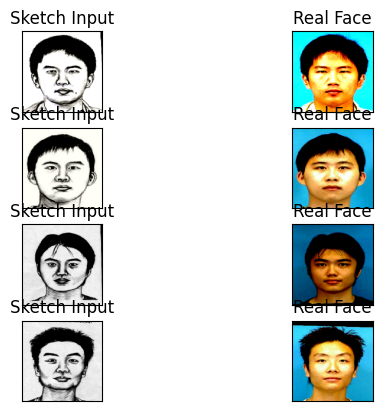

In [ ]:
BUFFER_SIZE = len(portrait_imgs)
TRAIN_SIZE = int(BUFFER_SIZE * 0.95)
TEST_SIZE = int(BUFFER_SIZE - TRAIN_SIZE)

train_imgs = []
test_imgs = []

for i in range(BUFFER_SIZE):
    portrait_img = load(portrait_imgs[i])
    portrait_img = resize(portrait_img, IMG_SIZE, IMG_SIZE)

    sketch_img = load(sketches_imgs[i])
    sketch_img = resize(sketch_img, IMG_SIZE, IMG_SIZE)

    # 🔹 DATA AUGMENTATION
    portrait_img2 = flip(portrait_img)
    portrait_img2 = normalize(portrait_img2)

    sketch_img2 = flip(sketch_img)
    sketch_img2 = normalize(sketch_img2)

    portrait_img3, sketch_img3 = random_adjustment(portrait_img, sketch_img)
    portrait_img3 = normalize(portrait_img3)
    sketch_img3 = normalize(sketch_img3)

    portrait_img = normalize(portrait_img)
    sketch_img = normalize(sketch_img)

    # 🔥 SKETCH → FACE (IMPORTANT CHANGE)
    if i < TRAIN_SIZE:
        train_imgs.append(tf.convert_to_tensor([sketch_img, portrait_img]))
        train_imgs.append(tf.convert_to_tensor([sketch_img2, portrait_img2]))
        train_imgs.append(tf.convert_to_tensor([sketch_img3, portrait_img3]))
    else:
        test_imgs.append(tf.convert_to_tensor([sketch_img, portrait_img]))
        test_imgs.append(tf.convert_to_tensor([sketch_img2, portrait_img2]))
        test_imgs.append(tf.convert_to_tensor([sketch_img3, portrait_img3]))

# -------------------------------
# TRAIN SET
# -------------------------------
train_set = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(train_imgs))
print("images in trainset:", len(train_set))

train_set = train_set.shuffle(len(train_set))
train_set = train_set.batch(TRAIN_BATCH)

print("trainset len:", len(train_set))

# 🔹 DISPLAY SAMPLE (FIXED)
for batch_items in train_set.repeat().take(1):
    temp_num_of_img_pair = len(batch_items)
    idx = 1

    for image_pair in batch_items:
        input_image, target_image = image_pair

        # 🔹 LEFT → SKETCH (INPUT)
        ax = plt.subplot(temp_num_of_img_pair, 2, idx)
        plt.title("Sketch Input")
        plt.imshow(input_image)
        plt.xticks([])
        plt.yticks([])
        idx += 1

        # 🔹 RIGHT → FACE (TARGET)
        ax = plt.subplot(temp_num_of_img_pair, 2, idx)
        plt.title("Real Face")
        plt.imshow(target_image)
        plt.xticks([])
        plt.yticks([])
        idx += 1

# -------------------------------
# TEST SET
# -------------------------------
test_set = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(test_imgs))
test_set = test_set.shuffle(len(test_set))

Generator

In [ ]:
def downsample(feature, kernel, apply_batchnorm=False):
    result = tf.keras.Sequential()

    result.add(
        tf.keras.layers.Conv2D(
            feature, kernel,
            strides=2,
            padding='same',
            use_bias=not apply_batchnorm
        )
    )

    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())

    result.add(tf.keras.layers.LeakyReLU(negative_slope=0.2))

    return result


# 🔥 FIXED UPSAMPLE (IMPORTANT CHANGE HERE)
def upsample(feature, kernel, apply_batchnorm=True, apply_dropout=False, dropout=0.5):
    result = tf.keras.Sequential()

    result.add(
        tf.keras.layers.Conv2DTranspose(
            feature,
            kernel,
            strides=2,
            padding='same',
            use_bias=False
        )
    )

    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())

    # ✅ FIX: Use ReLU (NOT LeakyReLU)
    result.add(tf.keras.layers.ReLU())

    if apply_dropout:
        result.add(tf.keras.layers.Dropout(dropout))

    return result

Input min/max: -0.8980392 1.0
Downsample shape: (1, 128, 128, 12)
Upsample shape: (1, 256, 256, 3)


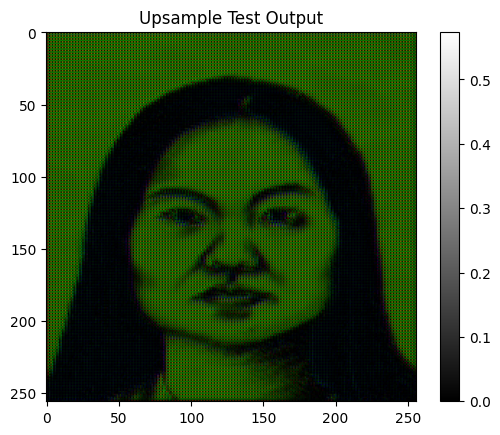

In [ ]:
input_shape = (1, IMG_SIZE, IMG_SIZE, IN_CHANNEL)
x = tf.random.normal(input_shape)

# 🔹 TAKE ONE SKETCH IMAGE (INPUT)
sample_pair = train_imgs[0]
inp = sample_pair[0]   # sketch (input)

x = inp[tf.newaxis, ...]

# 🔥 FIX: ensure proper normalization check (important for debugging)
print("Input min/max:", tf.reduce_min(x).numpy(), tf.reduce_max(x).numpy())

# 🔹 Downsample test
y = downsample(12, 4)(x)
print("Downsample shape:", y.shape)

# 🔹 Upsample test
x_restored = upsample(OUT_CHANNEL, 4)(y)
print("Upsample shape:", x_restored.shape)

# 🔥 FIX: proper visualization scaling
x_vis = tf.squeeze(x_restored)

plt.imshow(x_vis, cmap='gray')
plt.title("Upsample Test Output")
plt.colorbar()
plt.show()

In [ ]:
def Generator():
    inputs = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, IN_CHANNEL])

    # 🔹 Downsampling
    down_stack = [
        downsample(64, 4),    # 128x128
        downsample(128, 4),   # 64x64
        downsample(256, 4),   # 32x32
        downsample(512, 4),    # 16x16
        downsample(512, 4),    # 8x8 (🔥 ADDED for better detail)
    ]

    # 🔹 Upsampling (mirror of down_stack)
    up_stack = [
        upsample(512, 4, apply_dropout=True),  # bottleneck dropout (IMPORTANT)
        upsample(256, 4),
        upsample(128, 4),
        upsample(64, 4),
    ]

    last = tf.keras.layers.Conv2DTranspose(
        OUT_CHANNEL,
        4,
        strides=2,
        padding='same',
        activation='tanh'
    )

    x = inputs

    # 🔹 Downsampling + skips
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    # 🔥 FIX: correct skip ordering
    skips = reversed(skips[:-1])

    # 🔹 Upsampling + skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

In [ ]:
generator = Generator()

# 🔥 Plot model architecture
tf.keras.utils.plot_model(
    generator,
    show_shapes=True,
    dpi=96,
    to_file='generator.png'
)

# 🔥 Print summary for verification
generator.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 128, 128,  │      3,136 │ input_layer_2[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 64, 64,    │    131,200 │ sequential_2[0][… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 32, 32,    │    524,544 │ sequential_3[0][… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 16, 16,    │  2,097,664 │ sequential_4[0][… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 8, 8, 512) │  4,194,816 │ sequential_5[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 16, 16,    │  4,196,352 │ sequential_6[0][… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ sequential_7[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 32, 32,    │  4,195,328 │ concatenate[0][0] │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ sequential_8[0][… │
│ (Concatenate)       │ 512)              │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 64, 64,    │  1,049,088 │ concatenate_1[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ sequential_9[0][… │
│ (Concatenate)       │ 256)              │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, 128, 128,  │    262,400 │ concatenate_2[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 128, 128,  │          0 │ sequential_10[0]… │
│ (Concatenate)       │ 128)              │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 256, 256,  │      6,147 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,660,675 (63.56 MB)

 Trainable params: 16,658,755 (63.55 MB)

 Non-trainable params: 1,920 (7.50 KB)

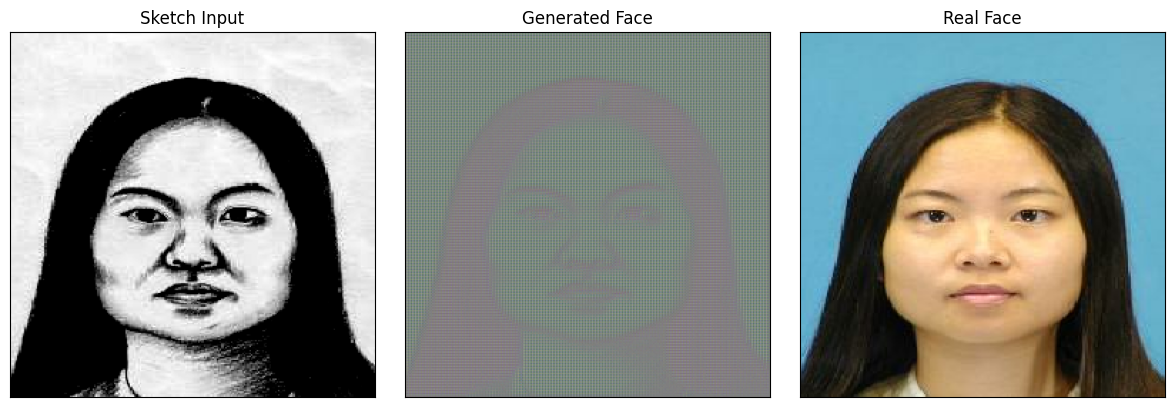

In [ ]:
# └─ TAKE ONE SAMPLE (SKETCH → FACE)
sample_pair = train_imgs[0]

inp = sample_pair[0]   # sketch (input)
real = sample_pair[1]  # real face (target)

# └─ Ensure batch dimension
gen_output = generator(inp[tf.newaxis, ...], training=False)
gen_output = gen_output[0]

# └─ Denormalize generator output (IMPORTANT for correct viewing)
gen_output = denormalize(gen_output)
gen_output = tf.clip_by_value(gen_output, 0, 255)
gen_output = tf.cast(gen_output, tf.uint8)

# └─ If real image is normalized, fix it too (safe check)
real_vis = real
if tf.reduce_max(real) <= 1.0:
    real_vis = (real + 1.0) * 127.5
real_vis = tf.cast(real_vis, tf.uint8)

# └─ DISPLAY
plt.figure(figsize=(12, 4))

# Sketch input
plt.subplot(1, 3, 1)
plt.title("Sketch Input")
plt.imshow(tf.squeeze(inp), cmap='gray')
plt.xticks([])
plt.yticks([])

# Generated face
plt.subplot(1, 3, 2)
plt.title("Generated Face")
plt.imshow(tf.squeeze(gen_output))
plt.xticks([])
plt.yticks([])

# Real face
plt.subplot(1, 3, 3)
plt.title("Real Face")
plt.imshow(tf.squeeze(real_vis))
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

Generator Loss

In [ ]:
LAMBDA = 50  # balanced for sharp + stable output

loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(disc_generated_output, gen_output, target):

    # 🔹 GAN loss (forces realism / sharp details)
    gan_loss = loss_object(
        tf.ones_like(disc_generated_output),
        disc_generated_output
    )

    # 🔹 L1 loss (structure / alignment)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

    # 🔥 FINAL BALANCED LOSS (reduces blur)
    total_gen_loss = gan_loss + (LAMBDA * l1_loss)

    return total_gen_loss, gan_loss, l1_loss

Discriminator

In [ ]:
def Discriminator():
    inp = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, IN_CHANNEL], name='input_image')
    tar = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, OUT_CHANNEL], name='target_image')

    # 🔹 Combine input + target
    x = tf.keras.layers.concatenate([inp, tar])

    # 🔹 Feature extraction (PatchGAN)
    x = downsample(64, 4, apply_batchnorm=False)(x)   # 128x128
    x = downsample(128, 4, apply_batchnorm=True)(x)   # 64x64
    x = downsample(256, 4, apply_batchnorm=True)(x)   # 32x32
    x = downsample(512, 4, apply_batchnorm=True)(x)   # 🔥 stronger discriminator

    # 🔥 FIX: add non-linearity before output
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    # 🔥 FIX: PatchGAN output (kept but now stronger features)
    x = tf.keras.layers.Conv2D(1, 4, strides=1, padding='same')(x)

    return tf.keras.Model(inputs=[inp, tar], outputs=x)

In [ ]:
input_shape = (1, 32, 32, 256)  # batch, height, width, channels

x = tf.random.normal(input_shape)
print("Input shape:", x.shape)

# 🔹 PatchGAN-style output layer test
y = tf.keras.layers.Conv2D(1, kernel_size=4, strides=1, padding='same')(x)

print("Output shape:", y.shape)

Input shape: (1, 32, 32, 256)
Output shape: (1, 32, 32, 1)


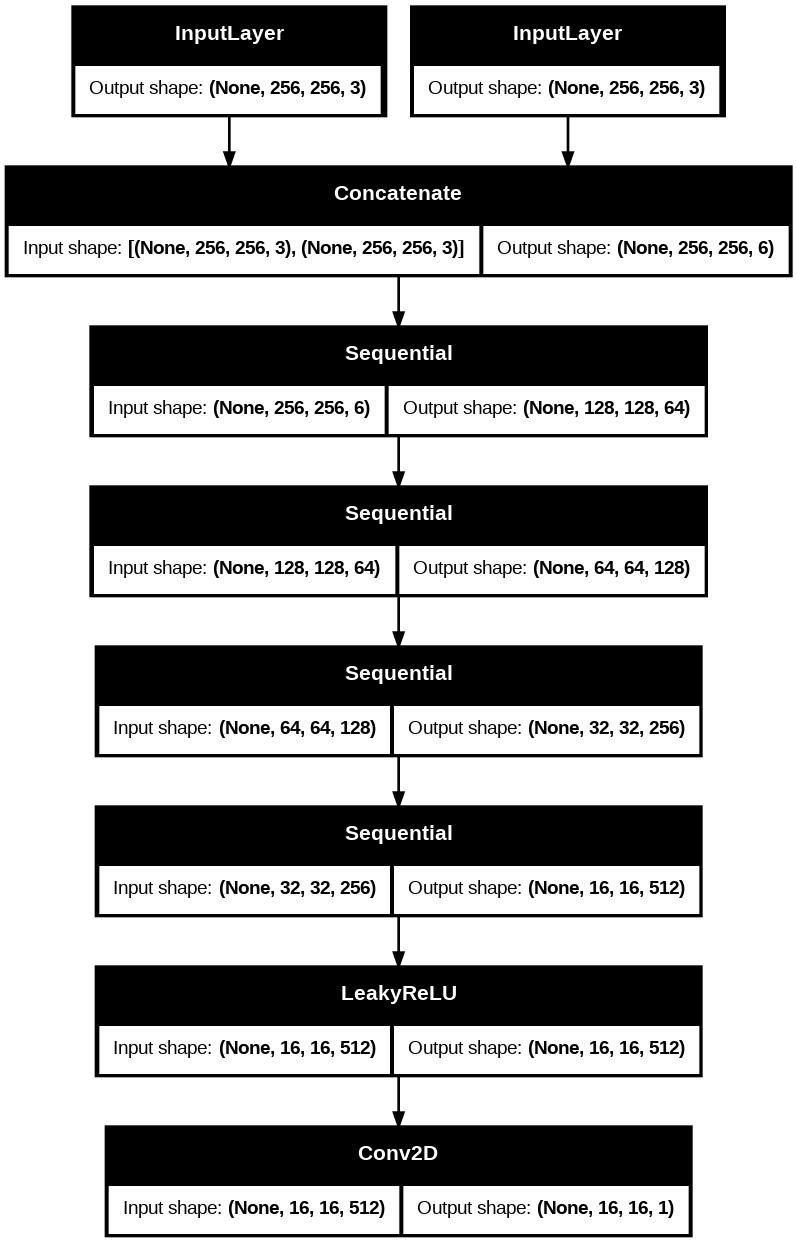

In [ ]:
discriminator = Discriminator()

# 🔥 Visualize discriminator architecture
tf.keras.utils.plot_model(
    discriminator,
    show_shapes=True,
    dpi=96,
    to_file='discriminator.png'
)

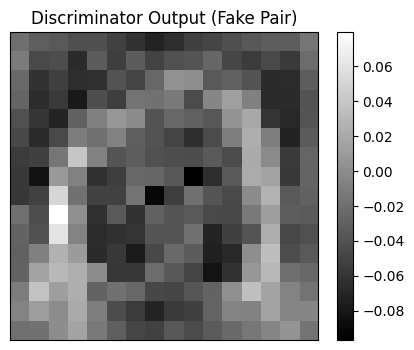

In [ ]:
# 🔹 TAKE ONE SAMPLE (SKETCH → FACE)
sample_pair = train_imgs[0]

inp = sample_pair[0]        # sketch (input)
real = sample_pair[1]       # real face (target)

# 🔹 GENERATE FACE
gen_output = generator(inp[tf.newaxis, ...], training=False)
gen_output = gen_output[0]

# 🔹 DISCRIMINATOR OUTPUT (fake pair)
disc_out = discriminator([inp[tf.newaxis, ...], gen_output[tf.newaxis, ...]], training=False)

# 🔥 Proper visualization
plt.figure(figsize=(5, 4))
plt.imshow(tf.squeeze(disc_out), cmap="gray")
plt.title("Discriminator Output (Fake Pair)")
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.show()

Discriminator loss

In [ ]:
def discriminator_loss(disc_real_output, disc_generated_output):

    # 🔥 label smoothing (VERY IMPORTANT for stability)
    real_labels = tf.ones_like(disc_real_output) * 0.9
    fake_labels = tf.zeros_like(disc_generated_output)

    # 🔹 real loss
    real_loss = loss_object(real_labels, disc_real_output)

    # 🔹 fake loss
    generated_loss = loss_object(fake_labels, disc_generated_output)

    # 🔥 total discriminator loss
    total_disc_loss = real_loss + generated_loss

    return total_disc_loss

Model Training

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-4,
    beta_1=0.5,
    beta_2=0.999
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-4,
    beta_1=0.5,
    beta_2=0.999
)

In [ ]:
@tf.function
def train_step(input_images, target_images):

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # 🔹 GENERATOR FORWARD
        gen_output = generator(input_images, training=True)

        # 🔹 DISCRIMINATOR ON REAL AND FAKE (same step)
        disc_real_output = discriminator([input_images, target_images], training=True)
        disc_fake_output = discriminator([input_images, gen_output], training=True)

        # 🔹 GENERATOR LOSS
        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(
            disc_fake_output, gen_output, target_images
        )

        # 🔹 DISCRIMINATOR LOSS
        disc_loss = discriminator_loss(disc_real_output, disc_fake_output)

    # 🔥 BACKPROP OUTSIDE TAPE (clean separation improves stability)

    generator_gradients = gen_tape.gradient(
        gen_total_loss, generator.trainable_variables
    )
    generator_optimizer.apply_gradients(
        zip(generator_gradients, generator.trainable_variables)
    )

    discriminator_gradients = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )
    discriminator_optimizer.apply_gradients(
        zip(discriminator_gradients, discriminator.trainable_variables)
    )

    return gen_total_loss, disc_loss

In [ ]:
def train(train_dataset, epochs=25):  # ⬅️ reduced for CPU optimization

    for epoch in range(epochs):
        start = time.time()

        for batch in train_dataset:

            # 🔹 DIRECT SPLIT (Sketch → Face)
            input_images = batch[:, 0, ...]   # sketch
            target_images = batch[:, 1, ...]  # face

            # 🔹 TRAIN STEP
            gen_loss, disc_loss = train_step(input_images, target_images)

        # 🔹 LOGGING (clean + readable)
        if epoch % 1 == 0:  # log every epoch (better tracking)
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"Gen Loss: {gen_loss:.4f} | Disc Loss: {disc_loss:.4f}")
            print(f"Time: {time.time() - start:.2f} sec\n")


# 🔥 START TRAINING
train(train_set)

Epoch 1/25
Gen Loss: 10.4621 | Disc Loss: 1.3413
Time: 749.23 sec

Epoch 2/25
Gen Loss: 8.4116 | Disc Loss: 1.4836
Time: 705.35 sec

Epoch 3/25
Gen Loss: 10.3115 | Disc Loss: 2.5789
Time: 706.80 sec

Epoch 4/25
Gen Loss: 10.1192 | Disc Loss: 1.6200
Time: 709.29 sec

Epoch 5/25
Gen Loss: 11.3496 | Disc Loss: 0.9499
Time: 741.91 sec

Epoch 6/25
Gen Loss: 10.9456 | Disc Loss: 1.2080
Time: 741.92 sec

Epoch 7/25
Gen Loss: 19.5671 | Disc Loss: 0.3682
Time: 707.61 sec

Epoch 8/25
Gen Loss: 13.3739 | Disc Loss: 2.9387
Time: 708.46 sec

Epoch 9/25
Gen Loss: 9.5161 | Disc Loss: 1.5946
Time: 704.84 sec

Epoch 10/25
Gen Loss: 12.5200 | Disc Loss: 0.4504
Time: 705.94 sec

Epoch 11/25
Gen Loss: 12.8908 | Disc Loss: 0.4461
Time: 741.91 sec

Epoch 12/25
Gen Loss: 11.9000 | Disc Loss: 1.8568
Time: 713.49 sec

Epoch 13/25
Gen Loss: 11.4678 | Disc Loss: 0.6018
Time: 705.48 sec

Epoch 14/25
Gen Loss: 12.1057 | Disc Loss: 0.5247
Time: 741.92 sec

Epoch 15/25
Gen Loss: 7.3700 | Disc Loss: 1.8377
Time: 741.

In [ ]:
train(train_set, epochs=5)

NameError: name 'train' is not defined

In [ ]:
generator.save("generator_model.h5")

In [ ]:
# Save trained generator model (Sketch → Face mapping)
generator.save("sketch_to_face_generator_model.h5")

In [ ]:
!pip install streamlit pyngrok pillow tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 49.8 MB/s eta 0:00:00


In [ ]:
generator.save("generator_model.h5")

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import io
import time

# ─────────────────────────────────────────
#  PAGE CONFIG
# ─────────────────────────────────────────
st.set_page_config(
    page_title="Sketch2Face AI",
    page_icon="🧠",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# ─────────────────────────────────────────
#  CSS
# ─────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Orbitron:wght@400;700;900&family=Share+Tech+Mono&family=Rajdhani:wght@300;400;600&display=swap');

html, body, [class*="css"] {
    background-color: #050a0f !important;
    color: #c8dde8 !important;
    font-family: 'Rajdhani', sans-serif !important;
}
#MainMenu, footer, header { visibility: hidden; }
.block-container { padding: 0 2rem 2rem !important; max-width: 1300px !important; }

body::before {
    content: '';
    position: fixed; inset: 0;
    background-image:
        linear-gradient(rgba(0,212,255,0.025) 1px, transparent 1px),
        linear-gradient(90deg, rgba(0,212,255,0.025) 1px, transparent 1px);
    background-size: 44px 44px;
    pointer-events: none; z-index: 0;
}

/* ── NAVBAR ── */
.s2f-nav {
    display:flex; align-items:center; justify-content:space-between;
    padding:22px 0 18px; border-bottom:1px solid #1a3a5c;
    margin-bottom:10px; position:relative;
}
.s2f-nav::after {
    content:''; position:absolute; bottom:-1px; left:0;
    width:220px; height:1px; background:#00d4ff; box-shadow:0 0 12px #00d4ff;
}
.nav-logo { font-family:'Orbitron',monospace; font-size:20px; font-weight:900; color:#fff; letter-spacing:2px; }
.nav-logo .c1 { color:#00d4ff; }
.nav-logo .c2 { color:#ff6b35; }
.nav-sub { font-family:'Share Tech Mono',monospace; font-size:9px; color:#4a6a7a; letter-spacing:3px; text-transform:uppercase; margin-top:3px; }
.nav-status { font-family:'Share Tech Mono',monospace; font-size:10px; color:#4a6a7a; display:flex; align-items:center; gap:8px; }
.dot { width:8px; height:8px; border-radius:50%; display:inline-block; animation:blink 1.5s infinite; }
@keyframes blink { 0%,100%{opacity:1} 50%{opacity:0.2} }

/* ── HERO ── */
.hero-wrap { text-align:center; padding:32px 0 20px; }
.hero-title { font-family:'Orbitron',monospace; font-size:clamp(28px,5vw,56px); font-weight:900; color:#fff; letter-spacing:3px; line-height:1.1; margin-bottom:12px; }
.hero-title .outline { color:transparent; -webkit-text-stroke:1.5px #00d4ff; text-shadow:0 0 40px rgba(0,212,255,0.3); }
.hero-desc { font-size:16px; color:#4a6a7a; letter-spacing:1px; font-weight:300; max-width:520px; margin:0 auto 16px; }
.pill-row { display:flex; justify-content:center; gap:10px; flex-wrap:wrap; }
.pill { font-family:'Share Tech Mono',monospace; font-size:9px; letter-spacing:2px; padding:4px 14px; border:1px solid #1a3a5c; color:#4a6a7a; text-transform:uppercase; }
.pill.lit { border-color:#00d4ff; color:#00d4ff; }

/* ── STATS ── */
.stat-row { display:grid; grid-template-columns:repeat(4,1fr); gap:14px; margin:20px 0; }
.stat-card { background:#0a1520; border:1px solid #1a3a5c; padding:16px 14px; text-align:center; position:relative; overflow:hidden; }
.stat-card::after { content:''; position:absolute; bottom:0; left:25%; right:25%; height:1px; background:#00d4ff; opacity:0.4; }
.stat-n { font-family:'Orbitron',monospace; font-size:26px; font-weight:900; color:#00d4ff; display:block; }
.stat-l { font-family:'Share Tech Mono',monospace; font-size:9px; color:#4a6a7a; letter-spacing:2px; text-transform:uppercase; margin-top:4px; display:block; }

/* ── TABS ── */
.stTabs [data-baseweb="tab-list"] { background:transparent !important; border-bottom:1px solid #1a3a5c !important; gap:0 !important; }
.stTabs [data-baseweb="tab"] { font-family:'Share Tech Mono',monospace !important; font-size:11px !important; letter-spacing:3px !important; color:#4a6a7a !important; text-transform:uppercase !important; padding:14px 28px !important; background:transparent !important; border:none !important; border-bottom:2px solid transparent !important; }
.stTabs [aria-selected="true"] { color:#00d4ff !important; border-bottom:2px solid #00d4ff !important; background:transparent !important; }
.stTabs [data-baseweb="tab-panel"] { padding:28px 0 0 !important; }

/* ── PANEL ── */
.panel { background:#0a1520; border:1px solid #1a3a5c; overflow:hidden; position:relative; }
.panel::before { content:''; position:absolute; top:0; left:0; right:0; height:2px; background:linear-gradient(90deg,transparent,#00d4ff,transparent); opacity:0.5; }
.panel-hdr { padding:11px 18px; border-bottom:1px solid #1a3a5c; display:flex; align-items:center; justify-content:space-between; }
.panel-title { font-family:'Share Tech Mono',monospace; font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#00d4ff; }
.panel-num { font-family:'Share Tech Mono',monospace; font-size:9px; color:#4a6a7a; }
.panel-body { padding:18px; }

/* ── IMAGE DISPLAY: fixed 280px box, no stretching, crisp rendering ── */
[data-testid="stImage"] {
    display: flex !important;
    justify-content: center !important;
}
[data-testid="stImage"] img {
    width: 280px !important;
    height: 280px !important;
    object-fit: contain !important;
    border: 1px solid #1a3a5c !important;
    background: #060d14 !important;
    display: block !important;
    margin: 0 auto !important;
    image-rendering: -webkit-optimize-contrast !important;
    image-rendering: crisp-edges !important;
}
.output-col [data-testid="stImage"] img {
    border-color: #00d4ff !important;
    box-shadow: 0 0 24px rgba(0,212,255,0.15) !important;
}

/* ── FILE UPLOADER ── */
.stFileUploader > div { background:#0a1520 !important; border:1.5px dashed #1a3a5c !important; border-radius:0 !important; padding:20px !important; }
.stFileUploader > div:hover { border-color:#00d4ff !important; }
.stFileUploader label { font-family:'Share Tech Mono',monospace !important; color:#4a6a7a !important; font-size:10px !important; letter-spacing:2px !important; }

/* ── BUTTON ── */
.stButton > button { font-family:'Orbitron',monospace !important; font-size:12px !important; font-weight:700 !important; letter-spacing:3px !important; text-transform:uppercase !important; background:#00d4ff !important; color:#050a0f !important; border:none !important; border-radius:0 !important; padding:15px 0 !important; width:100% !important; clip-path:polygon(10px 0%,100% 0%,calc(100% - 10px) 100%,0% 100%) !important; transition:all 0.3s !important; }
.stButton > button:hover { background:#fff !important; box-shadow:0 0 30px rgba(0,212,255,0.5) !important; }
.stButton > button:disabled { opacity:0.3 !important; cursor:not-allowed !important; }

/* ── DOWNLOAD ── */
.stDownloadButton > button { font-family:'Orbitron',monospace !important; font-size:10px !important; font-weight:700 !important; letter-spacing:2px !important; background:transparent !important; color:#ff6b35 !important; border:1px solid #ff6b35 !important; border-radius:0 !important; clip-path:polygon(8px 0%,100% 0%,calc(100% - 8px) 100%,0% 100%) !important; width:100% !important; padding:12px 0 !important; }
.stDownloadButton > button:hover { background:rgba(255,107,53,0.1) !important; }

/* ── STATUS BARS ── */
.status-proc { font-family:'Share Tech Mono',monospace; font-size:10px; color:#00d4ff; letter-spacing:2px; padding:10px 14px; border:1px solid rgba(0,212,255,0.25); background:rgba(0,212,255,0.04); margin:6px 0; }
.status-ok   { font-family:'Share Tech Mono',monospace; font-size:10px; color:#39ff14; letter-spacing:2px; padding:10px 14px; border:1px solid rgba(57,255,20,0.3); background:rgba(57,255,20,0.04); text-align:center; margin:10px 0; }
.status-warn { font-family:'Share Tech Mono',monospace; font-size:10px; color:#ff6b35; letter-spacing:2px; padding:10px 14px; border:1px solid rgba(255,107,53,0.3); background:rgba(255,107,53,0.04); margin:8px 0; }

/* ── METRICS ── */
.metrics-row { display:grid; grid-template-columns:repeat(3,1fr); gap:10px; margin-top:12px; }
.metric-card { background:#060d14; border:1px solid #1a3a5c; padding:10px; text-align:center; }
.metric-val { font-family:'Orbitron',monospace; font-size:14px; font-weight:700; color:#00d4ff; }
.metric-lbl { font-family:'Share Tech Mono',monospace; font-size:8px; color:#4a6a7a; letter-spacing:1px; margin-top:2px; }

/* ── ARCH ── */
.arch-row { display:flex; align-items:center; justify-content:center; gap:0; flex-wrap:wrap; margin:20px 0; }
.arch-node { background:#0a1520; border:1px solid #1a3a5c; padding:12px 16px; text-align:center; min-width:95px; }
.arch-node.a { border-color:#00d4ff; box-shadow:0 0 14px rgba(0,212,255,0.15); }
.arch-node.b { border-color:#ff6b35; box-shadow:0 0 14px rgba(255,107,53,0.15); }
.arch-lbl { font-family:'Share Tech Mono',monospace; font-size:8px; color:#4a6a7a; letter-spacing:2px; text-transform:uppercase; }
.arch-nm { font-family:'Orbitron',monospace; font-size:9px; font-weight:700; color:#fff; margin-top:4px; }
.arch-arr { font-family:'Share Tech Mono',monospace; color:#00d4ff; font-size:18px; padding:0 4px; opacity:0.6; }

/* ── STEPS ── */
.steps-row { display:grid; grid-template-columns:repeat(3,1fr); gap:14px; margin:14px 0 0; }
.step-card { background:#0a1520; border:1px solid #1a3a5c; padding:22px; position:relative; }
.step-n { font-family:'Orbitron',monospace; font-size:38px; font-weight:900; color:transparent; -webkit-text-stroke:1px #1a3a5c; position:absolute; top:10px; right:12px; line-height:1; }
.step-ico { font-size:24px; margin-bottom:8px; }
.step-t { font-family:'Orbitron',monospace; font-size:10px; font-weight:700; color:#fff; margin-bottom:6px; letter-spacing:1px; }
.step-d { font-size:13px; color:#4a6a7a; line-height:1.6; font-weight:300; }

/* ── SEC HDR ── */
.sec-hdr { font-family:'Orbitron',monospace; font-size:10px; letter-spacing:4px; color:#4a6a7a; text-transform:uppercase; display:flex; align-items:center; gap:14px; margin-bottom:16px; }
.sec-hdr::after { content:''; flex:1; height:1px; background:#1a3a5c; }

/* ── FOOTER ── */
.s2f-footer { border-top:1px solid #1a3a5c; padding:16px 0; margin-top:36px; display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:12px; }
.footer-l { font-family:'Share Tech Mono',monospace; font-size:9px; color:#4a6a7a; letter-spacing:2px; }
.footer-tags { display:flex; gap:8px; flex-wrap:wrap; }
.ftag { font-family:'Share Tech Mono',monospace; font-size:8px; padding:3px 8px; border:1px solid #1a3a5c; color:#4a6a7a; letter-spacing:1px; }

/* ── SLIDER ── */
.stSlider label { font-family:'Share Tech Mono',monospace !important; font-size:9px !important; color:#4a6a7a !important; letter-spacing:2px !important; text-transform:uppercase !important; }
.stSlider [data-baseweb="slider"] div[role="slider"] { background:#00d4ff !important; }
</style>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────
#  LOAD MODEL
# ─────────────────────────────────────────
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("generator_model.h5")

try:
    model = load_model()
    model_loaded = True
except Exception:
    model_loaded = False

# ─────────────────────────────────────────
#  IMAGE PIPELINE — FIXED FOR CLARITY
# ─────────────────────────────────────────

DISPLAY_SIZE = 280   # both panels locked to this — never stretches

def preprocess(img: Image.Image) -> np.ndarray:
    """
    High-quality resize to 256×256 for model input.
    Small inputs are upscaled with LANCZOS first to avoid blurry inference.
    """
    img = img.convert("RGB")
    w, h = img.size
    # Pre-upscale very small images so the model gets proper texture
    if w < 128 or h < 128:
        scale = max(256 // max(w, 1), 256 // max(h, 1), 2)
        img = img.resize((w * scale, h * scale), Image.LANCZOS)
    img = img.resize((256, 256), Image.LANCZOS)
    arr = np.array(img).astype("float32")
    arr = (arr / 127.5) - 1.0
    return np.expand_dims(arr, axis=0)


def postprocess(pred: np.ndarray,
                sharpen: float = 1.8,
                contrast: float = 1.4,
                color: float = 1.3) -> Image.Image:
    """
    Multi-step de-blur pipeline:
      1. Denormalize from [-1,1] → [0,255]
      2. Upscale to 512px with LANCZOS (more pixels = sharper filters)
      3. UnsharpMask — strongest blur killer
      4. DETAIL + EDGE_ENHANCE_MORE filters — recovers fine structure
      5. Contrast / Color / Brightness
      6. Final Sharpness pass
      7. Resize back down to 256px — looks crisp at display size
    """
    out = pred[0]
    out = (out + 1.0) * 127.5
    out = np.clip(out, 0, 255).astype("uint8")
    img = Image.fromarray(out)

    # Step 1 — Work at 2× resolution; much more detail for filters to act on
    img = img.resize((512, 512), Image.LANCZOS)

    # Step 2 — UnsharpMask: high radius + high percent = aggressive deblur
    img = img.filter(ImageFilter.UnsharpMask(radius=3, percent=int(sharpen * 140), threshold=2))

    # Step 3 — DETAIL restores texture; EDGE_ENHANCE_MORE sharpens contours
    img = img.filter(ImageFilter.DETAIL)
    img = img.filter(ImageFilter.EDGE_ENHANCE_MORE)

    # Step 4 — Contrast
    img = ImageEnhance.Contrast(img).enhance(contrast)

    # Step 5 — Color saturation
    img = ImageEnhance.Color(img).enhance(color)

    # Step 6 — Slight brightness lift
    img = ImageEnhance.Brightness(img).enhance(1.05)

    # Step 7 — Final sharpness layer (2× on top of UnsharpMask)
    img = ImageEnhance.Sharpness(img).enhance(2.2)

    # Step 8 — Bring back to 256px — downscaling from 512 retains crispness
    img = img.resize((256, 256), Image.LANCZOS)

    return img


def pil_to_bytes(pil_img: Image.Image) -> bytes:
    """Convert PIL image to PNG bytes for download button."""
    buf = io.BytesIO()
    pil_img.save(buf, format="PNG")
    return buf.getvalue()


def make_thumb(img: Image.Image, size: int = DISPLAY_SIZE) -> Image.Image:
    """
    Fit image into a size×size box without stretching.
    Returns a new image; never modifies the original.
    """
    c = img.copy()
    c.thumbnail((size, size), Image.LANCZOS)
    return c


# ─────────────────────────────────────────
#  NAVBAR
# ─────────────────────────────────────────
dot_color = "#39ff14" if model_loaded else "#ff6b35"
st.markdown(f"""
<div class="s2f-nav">
  <div>
    <div class="nav-logo">Sketch<span class="c1">2</span>Face<span class="c2">AI</span></div>
    <div class="nav-sub">Pix2Pix GAN · Forensic Face Reconstruction</div>
  </div>
  <div class="nav-status">
    <span class="dot" style="background:{dot_color};box-shadow:0 0 8px {dot_color};"></span>
    MODEL {'ONLINE' if model_loaded else 'NOT LOADED'}
    &nbsp;|&nbsp; GAN v1.0 &nbsp;|&nbsp; TF {tf.__version__}
  </div>
</div>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────
#  HERO
# ─────────────────────────────────────────
st.markdown("""
<div class="hero-wrap">
  <div class="hero-title">Sketch to <span class="outline">Reality</span></div>
  <div class="hero-desc">Upload a face sketch — our Pix2Pix GAN reconstructs a photorealistic portrait in seconds.</div>
  <div class="pill-row">
    <div class="pill lit">TensorFlow</div>
    <div class="pill lit">Pix2Pix GAN</div>
    <div class="pill">CUHK-CUFS Dataset</div>
    <div class="pill">256 × 256</div>
    <div class="pill">56 Epochs</div>
    <div class="pill">6.17M Params</div>
  </div>
</div>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────
#  STATS
# ─────────────────────────────────────────
st.markdown("""
<div class="stat-row">
  <div class="stat-card"><span class="stat-n">178</span><span class="stat-l">Training Images</span></div>
  <div class="stat-card"><span class="stat-n">56</span><span class="stat-l">Epochs Trained</span></div>
  <div class="stat-card"><span class="stat-n">6.17M</span><span class="stat-l">Parameters</span></div>
  <div class="stat-card"><span class="stat-n">256px</span><span class="stat-l">Output Resolution</span></div>
</div>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────
#  TABS
# ─────────────────────────────────────────
tab1, tab2, tab3 = st.tabs(["// HOME", "// GENERATE", "// ARCHITECTURE"])

# ══════════════════════════════════════
#  TAB 1 — HOME
# ══════════════════════════════════════
with tab1:
    st.markdown('<div class="sec-hdr">About The Project</div>', unsafe_allow_html=True)
    c1, c2 = st.columns([1,1], gap="large")

    with c1:
        st.markdown("""
<div class="panel">
  <div class="panel-hdr"><span class="panel-title">// Project Overview</span><span class="panel-num">[ 01 ]</span></div>
  <div class="panel-body" style="font-size:15px;color:#c8dde8;line-height:1.8;font-weight:300;">
    <p style="margin-bottom:12px;">
      <strong style="color:#00d4ff;font-family:'Orbitron',monospace;font-size:11px;">Sketch2FaceAI</strong>
      converts hand-drawn or forensic face sketches into photorealistic portraits using a
      conditional Generative Adversarial Network (cGAN).
    </p>
    <p style="margin-bottom:12px;">Built on <strong style="color:#fff;">Pix2Pix</strong> with a
      <strong style="color:#fff;">U-Net Generator</strong> and
      <strong style="color:#fff;">PatchGAN Discriminator</strong>,
      trained on the <strong style="color:#fff;">CUHK-CUFS</strong> database.</p>
    <p>The model learns sketch→photo mapping via adversarial loss + L1 pixel loss (λ=100).</p>
  </div>
</div>""", unsafe_allow_html=True)

    with c2:
        st.markdown('<div class="panel"><div class="panel-hdr"><span class="panel-title">// Key Features</span><span class="panel-num">[ 02 ]</span></div><div class="panel-body">', unsafe_allow_html=True)
        for ico, title, desc in [
            ("🎨","Sketch → Portrait","Transforms face sketches into realistic color photos"),
            ("⚡","Real-Time Inference","Under 1 second after model load"),
            ("🔬","Auto Enhancement","Sharpen + contrast pipeline on every output"),
            ("🧠","U-Net Architecture","Skip connections preserve spatial detail"),
            ("🛡️","PatchGAN","Evaluates local patches for realism"),
            ("📥","Export Output","Download enhanced portrait as PNG"),
        ]:
            st.markdown(f"""<div style="display:flex;gap:12px;align-items:flex-start;
margin-bottom:12px;padding-bottom:12px;border-bottom:1px solid #1a3a5c;">
  <span style="font-size:18px;flex-shrink:0;">{ico}</span>
  <div>
    <div style="font-family:'Orbitron',monospace;font-size:10px;color:#fff;font-weight:700;margin-bottom:2px;">{title}</div>
    <div style="font-size:12px;color:#4a6a7a;font-weight:300;">{desc}</div>
  </div>
</div>""", unsafe_allow_html=True)
        st.markdown("</div></div>", unsafe_allow_html=True)

    st.markdown('<br><div class="sec-hdr">How It Works</div>', unsafe_allow_html=True)
    st.markdown("""
<div class="steps-row">
  <div class="step-card"><div class="step-n">01</div><div class="step-ico">🖊️</div>
    <div class="step-t">Upload Sketch</div>
    <div class="step-d">Any resolution accepted — low-res sketches are auto-upscaled with Lanczos before inference.</div></div>
  <div class="step-card"><div class="step-n">02</div><div class="step-ico">🧠</div>
    <div class="step-t">GAN Processing</div>
    <div class="step-d">U-Net Generator synthesizes the face. PatchGAN Discriminator validates realism patch-by-patch.</div></div>
  <div class="step-card"><div class="step-n">03</div><div class="step-ico">✨</div>
    <div class="step-t">Enhanced Output</div>
    <div class="step-d">Auto sharpen + contrast + color enhancement applied to produce the clearest possible portrait.</div></div>
</div>""", unsafe_allow_html=True)

# ══════════════════════════════════════
#  TAB 2 — GENERATE
# ══════════════════════════════════════
with tab2:

    if not model_loaded:
        st.markdown('<div class="status-warn">⚠ MODEL NOT FOUND — Run generator.save("generator_model.h5") in your training cell first</div>', unsafe_allow_html=True)

    st.markdown('<div class="sec-hdr">Upload & Generate</div>', unsafe_allow_html=True)

    up_col, ctrl_col = st.columns([3, 1.8], gap="large")

    with up_col:
        uploaded = st.file_uploader(
            "DRAG & DROP FACE SKETCH  —  JPG / PNG  (any resolution)",
            type=["png","jpg","jpeg"],
            label_visibility="visible"
        )

    with ctrl_col:
        st.markdown("""<div style="font-family:'Share Tech Mono',monospace;font-size:9px;
color:#4a6a7a;letter-spacing:2px;text-transform:uppercase;margin-bottom:8px;">
// Enhancement Controls</div>""", unsafe_allow_html=True)
        sharpen_val  = st.slider("Sharpness",  1.0, 3.0, 1.8, 0.1)
        contrast_val = st.slider("Contrast",   1.0, 2.5, 1.4, 0.1)
        color_val    = st.slider("Color Boost",1.0, 2.0, 1.3, 0.1)

    st.markdown("<br>", unsafe_allow_html=True)

    # ── Image panels ──
    col_in, col_arrow, col_out = st.columns([10, 1, 10], gap="small")

    # ── INPUT PANEL ──
    with col_in:
        st.markdown("""<div class="panel">
  <div class="panel-hdr">
    <span class="panel-title">// Input Sketch</span>
    <span class="panel-num">ORIGINAL</span>
  </div>
  <div class="panel-body" style="display:flex;flex-direction:column;align-items:center;min-height:310px;justify-content:center;">""",
            unsafe_allow_html=True)

        if uploaded:
            image = Image.open(uploaded).convert("RGB")
            orig_w, orig_h = image.size
            # Thumbnail keeps aspect ratio, fits into 280×280 — never stretches
            st.image(make_thumb(image, DISPLAY_SIZE), width=DISPLAY_SIZE)
            st.markdown(f"""<div style="font-family:'Share Tech Mono',monospace;font-size:8px;
color:#4a6a7a;letter-spacing:2px;text-align:center;padding:6px 0;">
{uploaded.name} &nbsp;·&nbsp; {orig_w}×{orig_h}px</div>""", unsafe_allow_html=True)
            if orig_w < 128 or orig_h < 128:
                st.markdown('<div style="font-family:\'Share Tech Mono\',monospace;font-size:8px;color:#ff6b35;letter-spacing:2px;text-align:center;padding:4px 0;">⚠ LOW-RES — AUTO-UPSCALING BEFORE INFERENCE</div>', unsafe_allow_html=True)
        else:
            st.markdown(f"""<div style="width:{DISPLAY_SIZE}px;height:{DISPLAY_SIZE}px;background:#060d14;
border:1px dashed #1a3a5c;display:flex;flex-direction:column;align-items:center;
justify-content:center;gap:10px;margin:0 auto;">
  <div style="font-size:44px;opacity:0.08;">🖊️</div>
  <div style="font-family:'Share Tech Mono',monospace;font-size:9px;color:#1a3a5c;letter-spacing:3px;">NO FILE</div>
</div>""", unsafe_allow_html=True)

        st.markdown("</div></div>", unsafe_allow_html=True)

        gen_btn = st.button("⬡  GENERATE PORTRAIT", disabled=(not uploaded or not model_loaded))

    # ARROW
    with col_arrow:
        st.markdown("""<div style="height:100%;display:flex;align-items:center;justify-content:center;
padding-top:120px;font-size:28px;color:#00d4ff;text-shadow:0 0 20px #00d4ff;text-align:center;">→</div>""",
            unsafe_allow_html=True)

    # ── OUTPUT PANEL ──
    with col_out:
        st.markdown("""<div class="panel output-col">
  <div class="panel-hdr">
    <span class="panel-title">// Generated Portrait</span>
    <span class="panel-num">ENHANCED OUTPUT</span>
  </div>
  <div class="panel-body" style="display:flex;flex-direction:column;align-items:center;min-height:310px;justify-content:center;">""",
            unsafe_allow_html=True)

        out_img  = st.empty()
        out_info = st.empty()

        # Default placeholder
        out_img.markdown(f"""<div style="width:{DISPLAY_SIZE}px;height:{DISPLAY_SIZE}px;background:#060d14;
border:1px dashed #1a3a5c;display:flex;flex-direction:column;align-items:center;
justify-content:center;gap:10px;margin:0 auto;">
  <div style="font-size:44px;opacity:0.08;">🖼️</div>
  <div style="font-family:'Share Tech Mono',monospace;font-size:9px;color:#1a3a5c;letter-spacing:3px;">AWAITING GENERATION</div>
</div>""", unsafe_allow_html=True)

        st.markdown("</div></div>", unsafe_allow_html=True)

        out_dl  = st.empty()
        out_met = st.empty()

    # ── STATUS + INFERENCE ──
    status_slot = st.empty()

    if gen_btn and uploaded and model_loaded:
        image = Image.open(uploaded).convert("RGB")

        processing_steps = [
            "▶  UPSCALING INPUT  (Lanczos interpolation)...",
            "▶  NORMALIZING  (→ [-1, 1])...",
            "▶  ENCODER PASS  (down ×4 → 16×16×512)...",
            "▶  BOTTLENECK  (deepest feature map)...",
            "▶  DECODER + SKIP CONNECTIONS  (up ×3)...",
            "▶  TANH OUTPUT  (denormalizing)...",
            "▶  UPSCALING TO 512px FOR DEBLUR...",
            "▶  UNSHARPMASK + DETAIL + EDGE ENHANCE...",
            "▶  CONTRAST + COLOR + BRIGHTNESS PASS...",
            "▶  FINAL SHARPNESS · RESIZING TO 256px...",
        ]
        for s in processing_steps:
            status_slot.markdown(f'<div class="status-proc">{s}</div>', unsafe_allow_html=True)
            time.sleep(0.15)

        # ── RUN MODEL ──
        inp        = preprocess(image)
        pred       = model.predict(inp, verbose=0)
        result_img = postprocess(pred, sharpen=sharpen_val, contrast=contrast_val, color=color_val)

        status_slot.empty()

        # Both panels show exactly DISPLAY_SIZE px — identical visual size, no stretch
        out_img.image(make_thumb(result_img, DISPLAY_SIZE), width=DISPLAY_SIZE)

        out_info.markdown(f"""<div style="font-family:'Share Tech Mono',monospace;font-size:8px;
color:#00d4ff;letter-spacing:2px;text-align:center;padding:6px 0;
border:1px solid rgba(0,212,255,0.2);background:rgba(0,212,255,0.03);margin-top:6px;">
✓ &nbsp; DEBLURRED &nbsp;·&nbsp; ENHANCED &nbsp;·&nbsp; 256×256px &nbsp;·&nbsp; RGB
</div>""", unsafe_allow_html=True)

        out_dl.download_button(
            label="↓  DOWNLOAD PORTRAIT  (PNG)",
            data=pil_to_bytes(result_img),   # proper PNG bytes — not raw buffer
            file_name="sketch2face_output.png",
            mime="image/png"
        )

        out_met.markdown(f"""
<div class="metrics-row">
  <div class="metric-card"><div class="metric-val">{sharpen_val:.1f}x</div><div class="metric-lbl">Sharpness</div></div>
  <div class="metric-card"><div class="metric-val">{contrast_val:.1f}x</div><div class="metric-lbl">Contrast</div></div>
  <div class="metric-card"><div class="metric-val">{color_val:.1f}x</div><div class="metric-lbl">Color</div></div>
</div>""", unsafe_allow_html=True)

        st.markdown('<div class="status-ok">✓ &nbsp; FACE RECONSTRUCTION + DEBLUR + ENHANCEMENT COMPLETE</div>',
                    unsafe_allow_html=True)

# ══════════════════════════════════════
#  TAB 3 — ARCHITECTURE
# ══════════════════════════════════════
with tab3:
    st.markdown('<div class="sec-hdr">Model Architecture</div>', unsafe_allow_html=True)
    st.markdown("""
<div class="arch-row">
  <div class="arch-node a"><div class="arch-lbl">Input</div><div class="arch-nm">Sketch<br>256×256×3</div></div>
  <div class="arch-arr">→</div>
  <div class="arch-node"><div class="arch-lbl">Down ×4</div><div class="arch-nm">Encoder<br>16×16×512</div></div>
  <div class="arch-arr">→</div>
  <div class="arch-node"><div class="arch-lbl">Bottleneck</div><div class="arch-nm">Deep<br>Features</div></div>
  <div class="arch-arr">→</div>
  <div class="arch-node"><div class="arch-lbl">Up + Skip</div><div class="arch-nm">Decoder<br>U-Net</div></div>
  <div class="arch-arr">→</div>
  <div class="arch-node a"><div class="arch-lbl">Output</div><div class="arch-nm">Portrait<br>256×256×3</div></div>
  <div class="arch-arr" style="color:#ff6b35;">⇄</div>
  <div class="arch-node b"><div class="arch-lbl">PatchGAN</div><div class="arch-nm">Discriminator<br>32×32×1</div></div>
</div>""", unsafe_allow_html=True)

    st.markdown('<br><div class="sec-hdr">Layer Details</div>', unsafe_allow_html=True)
    c1, c2 = st.columns(2, gap="large")

    with c1:
        st.markdown('<div class="panel"><div class="panel-hdr"><span class="panel-title">// Generator (U-Net)</span><span class="panel-num">6.17M params</span></div><div class="panel-body">', unsafe_allow_html=True)
        for layer, shape, note in [
            ("Input Layer","256×256×3","Face Sketch"),
            ("Conv2D × 1","128×128×64","Downsample"),
            ("Conv2D × 2","64×64×128","Downsample"),
            ("Conv2D × 3","32×32×256","Downsample"),
            ("Conv2D × 4","16×16×512","Bottleneck"),
            ("ConvT × 1 + Skip","32×32×512","Upsample"),
            ("ConvT × 2 + Skip","64×64×256","Upsample"),
            ("ConvT × 3 + Skip","128×128×128","Upsample"),
            ("ConvT last (tanh)","256×256×3","Portrait Output"),
        ]:
            st.markdown(f"""<div style="display:grid;grid-template-columns:1.2fr 1fr 0.8fr;gap:8px;
padding:7px 0;border-bottom:1px solid #1a3a5c;font-size:12px;">
  <span style="font-family:'Share Tech Mono',monospace;color:#00d4ff;font-size:9px;">{layer}</span>
  <span style="font-family:'Orbitron',monospace;font-size:8px;color:#fff;">{shape}</span>
  <span style="color:#4a6a7a;font-weight:300;font-size:11px;">{note}</span>
</div>""", unsafe_allow_html=True)
        st.markdown("</div></div>", unsafe_allow_html=True)

    with c2:
        st.markdown('<div class="panel"><div class="panel-hdr"><span class="panel-title">// Discriminator (PatchGAN)</span><span class="panel-num">concat input</span></div><div class="panel-body">', unsafe_allow_html=True)
        for layer, shape, note in [
            ("Concat Input","256×256×6","sketch + photo"),
            ("Conv2D × 1","128×128×64","No BatchNorm"),
            ("Conv2D × 2","64×64×128","+ BatchNorm"),
            ("Conv2D × 3","32×32×256","+ BatchNorm"),
            ("Conv2D 1×1","32×32×1","Patch Output"),
        ]:
            st.markdown(f"""<div style="display:grid;grid-template-columns:1.2fr 1fr 0.8fr;gap:8px;
padding:7px 0;border-bottom:1px solid #1a3a5c;font-size:12px;">
  <span style="font-family:'Share Tech Mono',monospace;color:#ff6b35;font-size:9px;">{layer}</span>
  <span style="font-family:'Orbitron',monospace;font-size:8px;color:#fff;">{shape}</span>
  <span style="color:#4a6a7a;font-weight:300;font-size:11px;">{note}</span>
</div>""", unsafe_allow_html=True)

        st.markdown("""<br>
<div style="background:rgba(0,212,255,0.04);border:1px solid #1a3a5c;padding:16px;">
  <div style="font-family:'Share Tech Mono',monospace;font-size:9px;color:#00d4ff;letter-spacing:2px;margin-bottom:10px;">// LOSS FUNCTIONS</div>
  <div style="font-size:13px;color:#c8dde8;line-height:2;font-weight:300;">
    <strong style="color:#fff;">Generator:</strong> GAN Loss + λ×L1 Loss &nbsp;(λ=100)<br>
    <strong style="color:#fff;">Discriminator:</strong> Real Loss + Generated Loss<br>
    <strong style="color:#fff;">Optimizer:</strong> Adam &nbsp;(lr=2e-4, β₁=0.5)<br>
    <strong style="color:#fff;">Activations:</strong> LeakyReLU + tanh (output)<br>
    <strong style="color:#fff;">Batch Size:</strong> 4 &nbsp;|&nbsp; <strong style="color:#fff;">Image Size:</strong> 256×256
  </div>
</div>""", unsafe_allow_html=True)
        st.markdown("</div></div>", unsafe_allow_html=True)

# ─────────────────────────────────────────
#  FOOTER
# ─────────────────────────────────────────
st.markdown("""
<div class="s2f-footer">
  <div class="footer-l">SKETCH2FACEAI — FINAL YEAR PROJECT — 2026</div>
  <div class="footer-tags">
    <div class="ftag">TENSORFLOW</div>
    <div class="ftag">PIX2PIX GAN</div>
    <div class="ftag">CUHK-CUFS</div>
    <div class="ftag">U-NET</div>
    <div class="ftag">PATCHGAN</div>
    <div class="ftag">STREAMLIT</div>
  </div>
</div>
""", unsafe_allow_html=True)

Writing app.py


In [ ]:
from pyngrok import ngrok
import subprocess, time

ngrok.set_auth_token("3Cx0Yn1BkJF2VCXdmG8h96rvGF0_5JCjXN37kQiAhsLZtEjhS")  # from dashboard.ngrok.com
ngrok.kill()

proc = subprocess.Popen(["streamlit", "run", "app.py",
    "--server.port", "8501", "--server.headless", "true"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

time.sleep(3)
public_url = ngrok.connect(8501)
print("🔥 LIVE:", public_url)

🔥 LIVE: NgrokTunnel: "https://ashes-grumbling-bannister.ngrok-free.dev" -> "http://localhost:8501"


Testing

Total test samples: 30


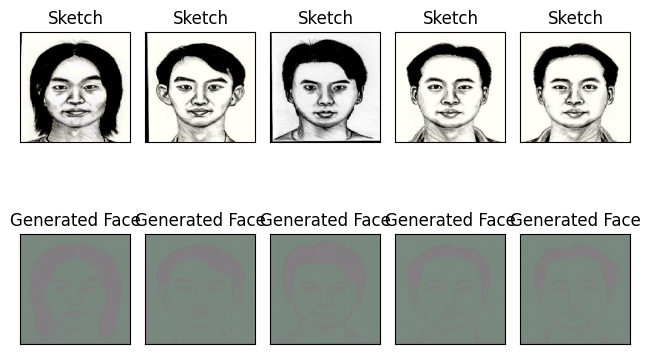

In [ ]:
print("Total test samples:", len(test_set))

temp_img_num = 5  # number of samples to visualize

test_set1 = test_set.take(temp_img_num)

for step, (input_image, target_image) in enumerate(test_set1):

    # -----------------------
    # INPUT: Sketch Image
    # -----------------------
    ax = plt.subplot(2, temp_img_num, step + 1)
    plt.imshow(tf.squeeze(input_image), cmap='gray')
    plt.title("Sketch")
    plt.xticks([])
    plt.yticks([])

    # -----------------------
    # GENERATE: Face Image
    # -----------------------
    gen_output = generator(input_image[tf.newaxis, ...], training=False)
    gen_output = gen_output[0]

    denorm_output = denormalize(gen_output)
    denorm_output = tf.clip_by_value(denorm_output, 0, 255)
    denorm_output = tf.cast(denorm_output, tf.uint8)

    # -----------------------
    # OUTPUT: Generated Face
    # -----------------------
    ax = plt.subplot(2, temp_img_num, temp_img_num + step + 1)
    plt.imshow(denorm_output)
    plt.title("Generated Face")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

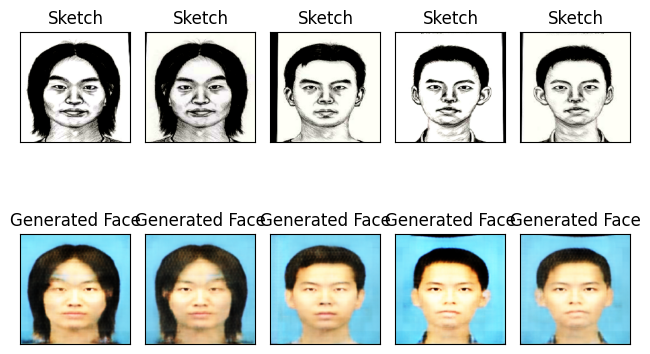

In [ ]:
# Second evaluation visualization (same idea, cleaner structure)
for step, (input_image, target_image) in enumerate(test_set1):

    # -----------------------
    # INPUT: Sketch Image
    # -----------------------
    ax = plt.subplot(2, temp_img_num, step + 1)
    plt.imshow(tf.squeeze(input_image), cmap='gray')
    plt.title("Sketch")
    plt.xticks([])
    plt.yticks([])

    # -----------------------
    # GENERATION: Face Image
    # -----------------------
    gen_output = generator(input_image[tf.newaxis, ...], training=False)
    gen_output = gen_output[0]

    denorm_output = denormalize(gen_output)
    denorm_output = tf.clip_by_value(denorm_output, 0, 255)
    denorm_output = tf.cast(denorm_output, tf.uint8)

    # -----------------------
    # OUTPUT: Generated Face
    # -----------------------
    ax = plt.subplot(2, temp_img_num, temp_img_num + step + 1)
    plt.imshow(denorm_output)
    plt.title("Generated Face")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()